In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
from subs1_utils import precompute_latitudes,bscst

In [20]:
kmax=26
imax=192
jmax=96

In [21]:
pressure=[  1.08486166,   4.88356359,  11.22881978,  20.86758022,
        33.73306385,  49.1263303 ,  65.57076192,  80.51359417,
        95.09554964, 112.2498516 , 132.43108077, 156.17318107,
       184.10433277, 216.96448554, 255.62270116, 301.10180985,
       354.70004899, 417.64863236, 491.60191382, 578.71926301,
       671.9904254 , 760.08638592, 837.10262179, 897.67801905,
       937.33557425, 958.65152444]

In [22]:
vert_struc=np.zeros((kmax))
vert_struc[0] = 0.0
vert_struc[1] = 0.0
vert_struc[2] = 0.0
vert_struc[3] = 0.0
vert_struc[4] = 0.0
vert_struc[5] = 0.25
vert_struc[6] = 0.5
vert_struc[7] = 0.75
vert_struc[8] = 0.75
vert_struc[9] = 1.0
vert_struc[10] = 1.0
vert_struc[11] = 1.25
vert_struc[12] = 1.25

vert_struc[13] = 1.5
vert_struc[14] = 1.5
vert_struc[15] = 1.75
vert_struc[16] = 1.75

vert_struc[17] = 2.0
vert_struc[18] = 2.0
vert_struc[19] = 2.0
vert_struc[20] = 2.0

vert_struc[21] = 0.75
vert_struc[22] = 0.5
vert_struc[23] = 0.25
vert_struc[24] = 0.0
vert_struc[25] = 0.0

/tmp/ipykernel_2777576/1228116633.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=12)


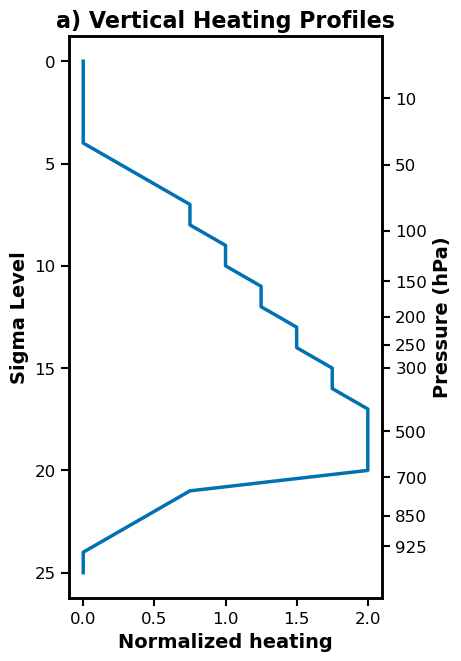

In [27]:
colors = ["#0072B2"]  # blue

# --- Create figure ---
fig, ax = plt.subplots(
    1, 1, figsize=(4.5, 6.5), constrained_layout=True
)
# --- Common styling function ---
def style_axes(ax):
    ax.tick_params(labelsize=12, width=1.5, length=6, direction="out")
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)


ax.plot(
    vert_struc,
    np.arange(kmax), lw=2.5, color=colors[0]
)
ax.invert_yaxis()
ax.set_xlabel("Normalized heating", fontsize=14, weight="bold")
ax.set_ylabel("Sigma Level", fontsize=14, weight="bold")
ax.legend(frameon=False, fontsize=12)
ax.set_title("a) Vertical Heating Profiles", fontsize=16, weight="bold")
style_axes(ax)


secax = ax.twinx()
secax.set_ylim(ax.get_ylim())  # align with main axis

standard_levels = np.array([1000, 925, 850, 700, 500, 300, 250, 200, 150, 100, 50, 10])
p_min, p_max = np.asarray(pressure).min(), np.asarray(pressure).max()
valid = (standard_levels >= p_min) & (standard_levels <= p_max)
levels_use = standard_levels[valid]

# compute where (in sigma index space) those pressure levels lie
index=index = np.arange(26)
tick_positions = np.interp(levels_use, pressure, index)

secax.set_yticks(tick_positions)
secax.set_yticklabels([f"{int(p)}" for p in levels_use])
secax.set_ylabel("Pressure (hPa)", fontsize=14, weight="bold")
style_axes(secax)

In [28]:
fig.savefig(
    "FigureS7.jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05,
)